In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# Load and visualise the dataset - MNIST

In [ ]:
np.random.seed(42)  # same random numbers every run

# Load MNIST
# Downloads ~12 MB the first time, cached afterwards
print('Loading MNIST...')
mnist   = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X_all   = mnist.data.astype(np.float32) / 255.0  # normalise pixels to [0, 1]
y_all   = mnist.target.astype(int)

# Use a subset of 10 000 for fast runs
# stratify=y ensures all 10 digit classes appear proportionally
X_sub, _, y_sub, _ = train_test_split(
    X_all, y_all, train_size=10_000, random_state=42, stratify=y_all
)

print(f'Subset shape : {X_sub.shape}   (10 000 samples × 784 pixels)')
print(f'Classes      : {np.unique(y_sub)}')

Loading MNIST...
Subset shape : (10000, 784)   (10 000 samples × 784 pixels)
Classes      : [0 1 2 3 4 5 6 7 8 9]


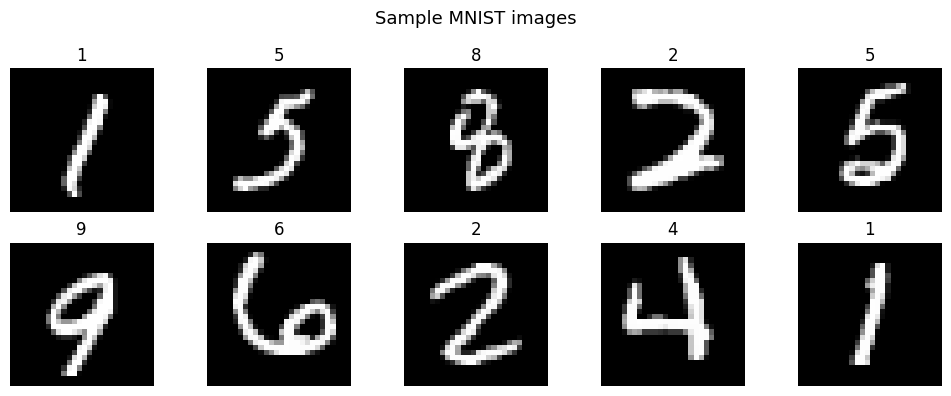

In [ ]:
# Visualise a few samples
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_sub[i].reshape(28, 28), cmap='gray')
    ax.set_title(str(y_sub[i])); ax.axis('off')
plt.suptitle('Sample MNIST images', fontsize=13)
plt.tight_layout()
plt.show()

# Split the dataset

> When we train a model we need **three separate buckets** of data:
>
> | Split | Purpose |
> |---|---|
> | **Train** | The model learns from this — weights are updated on it |
> | **Validation** | We *watch* the model here during training — did it actually generalise? |
> | **Test** | Final score — sealed until the very end, never used for any decision |

>
> **One-hot encoding:** our labels are integers (0–9). The output layer produces 10 numbers.  
> We encode label `3` as `[0,0,0,1,0,0,0,0,0,0]` so we can compute cross-entropy loss directly.

In [ ]:
# Split: 70% train, 15% val, 15% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X_sub, y_sub, test_size=0.15, random_state=42, stratify=y_sub
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15 / 0.85, random_state=42, stratify=y_temp
)

In [ ]:
print(f'Train : {X_train.shape[0]:>5} samples')
print(f'Val   : {X_val.shape[0]:>5} samples')
print(f'Test  : {X_test.shape[0]:>5} samples')

Train :  7000 samples
Val   :  1500 samples
Test  :  1500 samples


In [ ]:
# label k  →  a vector of zeros with a 1 in position k
def one_hot(y, n_classes=10):
    Y = np.zeros((len(y), n_classes))
    Y[np.arange(len(y)), y] = 1
    return Y

In [ ]:
Y_train = one_hot(y_train)  # (7000, 10)
Y_val   = one_hot(y_val)    # (1500, 10)
Y_test  = one_hot(y_test)   # (1500, 10)

# Activation functions

> - `relu` / `relu_grad` — activation and its derivative
> - `softmax` — turns raw scores into probabilities (needed for multi-class)
> - `cross_entropy_loss` — the right loss function when output is a probability distribution

ReLU: pass positives through, zero out negatives.

In [ ]:
def relu(z):
    return np.maximum(0, z)

  Derivative of ReLU: 1 where z > 0, else 0

In [ ]:
def relu_grad(z):
    return (z > 0).astype(float)

Softmax: converts raw scores into probabilities (positive, sum to 1).
Subtracting max(z) before exp() prevents numerical overflow — result is identical.


> **Key point about softmax + cross-entropy:**  
> When we differentiate softmax cross-entropy together, the gradient simplifies to just `(probs - Y) / n`.  
> That's why the output layer gradient in `backward()` looks so clean

In [ ]:
def softmax(z):
    z_stable = z - np.max(z, axis=1, keepdims=True)
    exp_z    = np.exp(z_stable)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

  Cross-entropy loss for multi-class classification.
  
      probs : softmax output  (n, 10)  — predicted probabilities
      Y     : one-hot labels  (n, 10)  — true distribution
  
  Returns the average loss over the batch (a single scalar).

In [ ]:
def cross_entropy_loss(probs, Y):
    n = Y.shape[0]
    return -np.sum(Y * np.log(probs + 1e-9)) / n  # 1e-9 avoids log(0)

In [1]:
def plot_history(history, title=''):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history['train_loss'], label='Train')
    ax1.plot(history['val_loss'],   label='Val', linestyle='--')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.set_title('Loss'); ax1.legend(); ax1.grid(True)

    ax2.plot(history['train_acc'], label='Train')
    ax2.plot(history['val_acc'],   label='Val', linestyle='--')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Accuracy'); ax2.legend(); ax2.grid(True)

    plt.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()